In [1]:
import argparse
import json
import logging
import csv

import os
import sys
sys.path.append("../..")
from pathlib import Path
from tqdm import tqdm

from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler
import torch
from monai.losses import PatchAdversarialLoss, PerceptualLoss
from monai.networks.nets import PatchDiscriminator
from monai.config import print_config
from monai.utils import set_determinism
from monai.data import CacheDataset, DataLoader, ThreadDataLoader
from torch.nn import L1Loss, MSELoss
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.tensorboard import SummaryWriter
import monai.transforms as transforms
import utils.custom_transforms as custom_transforms
import utils.simplex_ddpm as simplex_ddpm
import AnoDDPM.simplex as simplex

import numpy as np


import matplotlib.pyplot as plt

In [2]:
DEVICE_TYPE = "cuda:0"
device = torch.device(DEVICE_TYPE)

set_determinism(0)

#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:

IMAGE_SIZE = 128

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)


test_reconstruction_csv = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/final_flair_dataset_small/test.csv")
test_reconstruction_images_path = []

with open(test_reconstruction_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        test_reconstruction_images_path.append(ROOT_DIR+line[0])

#test_reconstruction_datalist = sorted(test_reconstruction_images_path)
test_reconstruction_datalist = test_reconstruction_images_path

#test_unhealthy_datalist = test_unhealthy_images_path

batch_size = 32
num_workers = 8


# transforms
test_reconstruction_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=450.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero(),
        #transforms.EnsureType(device=device, track_meta=False)
    ]
)
test_reconstruction_ds = CacheDataset(data=test_reconstruction_datalist, transform=test_reconstruction_transforms)
test_reconstruction_loader = DataLoader(
    test_reconstruction_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)


95it [00:00, 54086.99it/s]
Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [00:10<00:00,  8.88it/s]


In [4]:
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(128, 128, 256, 256),
    attention_levels=(False, True, True, True),
    num_head_channels=(0, 128, 128, 256),
)
model.to(device)

model_path = ROOT_DIR+"AnoDiffExperiments/best_models/experiment_3/exp_3_10_best_model.pth"

ckpt = torch.load(model_path, map_location=device)
# if the checkpoint is nested under "state_dict"
if isinstance(ckpt, dict) and "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
    ckpt = ckpt["state_dict"]

# remove "module." prefix if present (from DDP/DataParallel)
ckpt = {k.replace("module.", "", 1) if k.startswith("module.") else k: v for k, v in ckpt.items()}

missing_keys, unexpected_keys = model.load_state_dict(ckpt, strict=False)
if missing_keys or unexpected_keys:
    print(f"load_state_dict warnings — missing: {missing_keys}, unexpected: {unexpected_keys}")

model.eval()



DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler

In [5]:
infer_scheduler = simplex_ddpm.SimplexDDPMScheduler(num_train_timesteps=600, schedule="cosine")

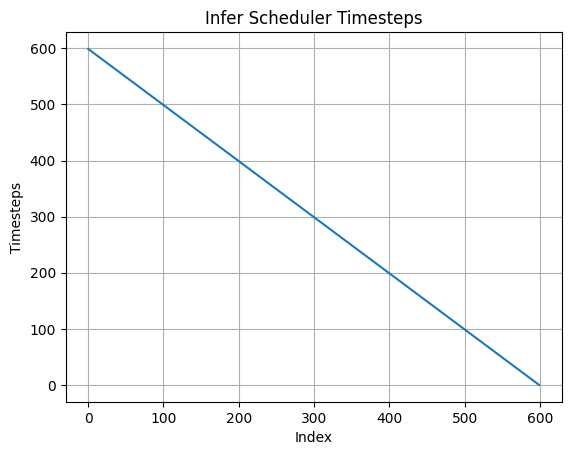

In [6]:

# Assuming infer_scheduler is defined in the context
timesteps = infer_scheduler.timesteps

plt.plot(timesteps.cpu().numpy())
plt.title("Infer Scheduler Timesteps")
plt.xlabel("Index")
plt.ylabel("Timesteps")
plt.grid()
plt.show()

In [ ]:
@torch.no_grad()
def my_sample(image, infer_scheduler, timesteps=100, return_intermediates=False):
    
    simplexObj = simplex.Simplex_CLASS()

    noise = simplex_ddpm.generate_simplex_noise(simplexObj, image.shape).to(device)
    print(noise.shape)

    if timesteps >= infer_scheduler.num_train_timesteps:
        print(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)

    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()

    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO


    intermediates = []
    intermediates_step = 20

            
    for t in range(timesteps, 0, -1): # va de timesteps à 0
        
        model_output = model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #print(model_output.shape)
        
        image, _ = infer_scheduler.step(model_output, t, image)
      
        if (t== timesteps-1 or t%intermediates_step == 0) and return_intermediates:
            intermediates.append(image)

    if return_intermediates:
        return image, intermediates
    else:
        return image

In [ ]:
batch = next(iter(test_reconstruction_loader))
batch = batch.to(device)

image, intermediates = my_sample(batch, infer_scheduler, timesteps=600, return_intermediates=True)

torch.Size([32, 1, 128, 128])
timesteps_list:
tensor([599, 599, 599, 599, 599, 599, 599, 599, 599, 599, 599, 599, 599, 599,
        599, 599, 599, 599, 599, 599, 599, 599, 599, 599, 599, 599, 599, 599,
        599, 599, 599, 599], device='cuda:0')
timesteps_list_random:
tensor([395,   5, 347, 356, 543, 349, 249, 163, 335, 583,  91, 478, 206, 387,
        418, 289, 439, 164, 146,  12, 226, 554, 221, 255, 479, 267,  56, 299,
        482, 462, 563, 438], device='cuda:0')


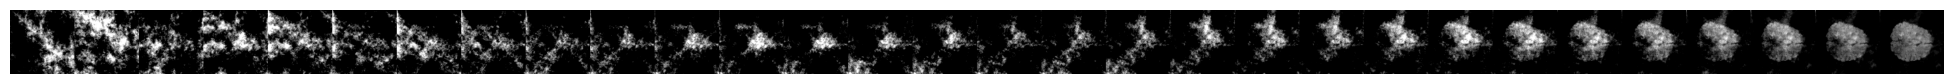

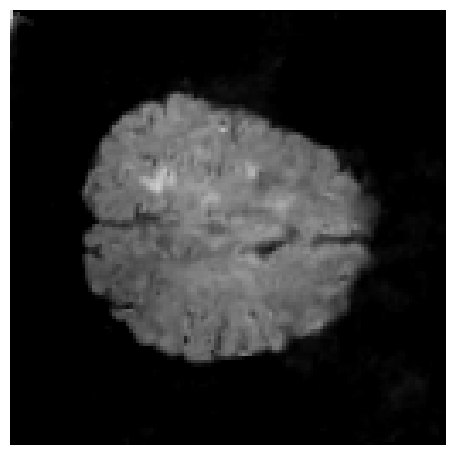

In [ ]:
# Assuming intermediates is a list of numpy arrays with shape (batch_size, channels, height, width)
# Extract the first image from the batch for each intermediate step
chain = torch.cat(intermediates, dim=-1)
plt.figure(figsize=(20, 5))
plt.imshow(chain[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(image[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()

In [ ]:
batch = next(iter(test_reconstruction_loader))
batch = batch.to(device)

image, intermediates = my_sample(batch, infer_scheduler, timesteps=200, return_intermediates=True)

torch.Size([32, 1, 128, 128])
timesteps_list:
tensor([200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
        200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
        200, 200, 200, 200], device='cuda:0')
timesteps_list_random:
tensor([ 33, 163,  84, 151, 175,  46, 106, 154,  23,  64, 155,  59,  71,  96,
         98,  60,  69, 179, 118, 188, 141, 160,   0,  32,  86,  80,  71, 151,
         58,  87,  50,  80], device='cuda:0')


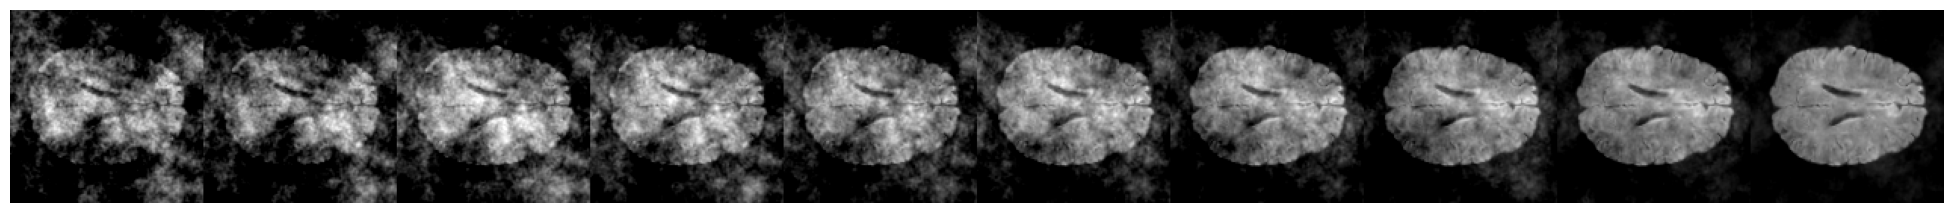

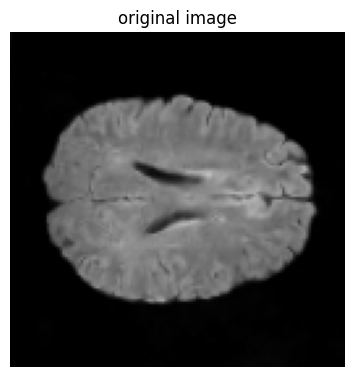

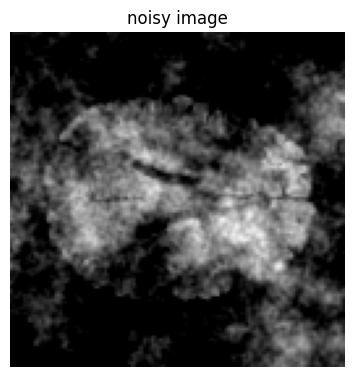

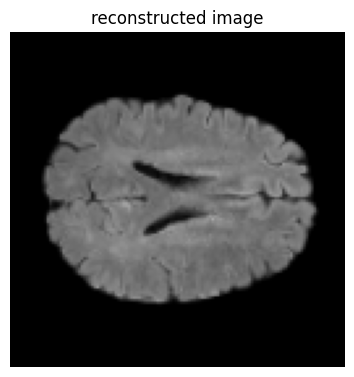

In [14]:
# Assuming intermediates is a list of numpy arrays with shape (batch_size, channels, height, width)
# Extract the first image from the batch for each intermediate step
chain = torch.cat(intermediates, dim=-1)
plt.figure(figsize=(20, 5))
plt.imshow(chain[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(image[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.title("original image")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(intermediates[1][0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.title("noisy image")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(batch[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.title("reconstructed image")
plt.show()